# [ML] Cold Threshold 탐색 — 2026-07-03

> **[업데이트, 2026-07-03 재실행]** 최초 실행 이후 [하이퍼파라미터 튜닝 노트북](./20260703_ML_als_hyperparameter_tuning.ipynb)에서
> `configs/ALS/params.yaml`의 ALS 설정이 `factors=64, alpha=1, regularization=0.01(기본값)` →
> `factors=16, alpha=0.5, regularization=10.0`으로 바뀌었다. 최초 실행 결과(ALS가 인기도를 어느 구간에서도
> 뚜렷이 못 이김)는 옛 설정 기준이었으므로, 새 설정으로 이 노트북을 처음부터 다시 실행해 결론이 달라지는지
> 확인한다. 아래 코드는 `params.yaml`을 그대로 읽어오므로 코드 자체는 수정하지 않았다 — `train_als()` 호출이
> 이미 현재 `configs/ALS/params.yaml` 값을 사용한다.

**목적**: ALS 추천과 인기도(popularity) 추천의 성능을 유저의 `train` 이벤트 수 구간별로 비교하여,
어느 지점부터 ALS가 인기도 추천보다 나은 성능을 내는지(`cold_threshold` 후보) 탐색적으로 파악한다.

**⚠️ 주의사항 (읽고 진행할 것)**
- 이 노트북은 **test set을 threshold 탐색에 사용**하는 탐색적(exploratory) 분석이다.
- `cold_threshold`를 여기서 확정하고 같은 test set으로 "최종 성능"을 보고하면 데이터 누수(하이퍼파라미터가 test 정답을 보고 선택됨)가 발생한다.
- 따라서 이 노트북에서 나온 threshold 후보는 **잠정치**이며, 실제 `configs/ALS/params.yaml`에 반영하기 전 별도 validation split을 구성해 재검증이 필요하다.
- 재현성: `np.random.seed(42)`, ALS `random_state=42` (`configs/ALS/params.yaml` 값 그대로 사용)

**데이터셋 버전**: `data/processed/als_events.csv` (전체 유저 기준, `make_als_mart.py` 산출물)
**분할 기준**: `configs/ALS/params.yaml`의 `split_date` (이벤트 레벨에서 시간 기준 분할, 집계 전에 먼저 수행)

**분석 항목**
1. 데이터 로드 & 기본 검사
2. Train/Test Split & ALS 학습 (기존 `als_model.py` 함수 재사용)
3. 전체 유저 대상 ALS 추천 vs 인기도 추천 동시 생성 (기존 파이프라인과 달리 세그먼트 구분 없이 전원에게 두 방식 모두 적용)
4. Ground Truth 구성 (purchase 이벤트만, train 유저/아이템에 존재하는 것만 — `als_model.py`와 동일 로직)
5. 유저 단위 지표 계산 (HR/Recall/NDCG@K)
6. train 이벤트 수 구간별 ALS vs 인기도 비교 및 시각화
7. Threshold 후보 도출 및 한계점

In [1]:
# 1. 표준 라이브러리
import logging
import sys
from pathlib import Path

# 2. 서드파티
import numpy as np
import pandas as pd

# 3. 시각화
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 프로젝트 루트를 sys.path에 추가 (notebooks/ 에서 실행 기준)
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.baselines.ALS.als_model import (
    PARAMS_PATH, load_params, load_events, split_events, aggregate_scores, build_sparse_matrix, train_als,
)
from src.baselines.ALS.als_evaluate import hit_rate_at_k, recall_at_k, ndcg_at_k, build_ground_truth

np.random.seed(42)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("cold_threshold_search")

# 한국어 폰트 설정 (Windows: Malgun Gothic / Mac: AppleGothic)
font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break
plt.rcParams["axes.unicode_minus"] = False

# 색약 친화 팔레트
palette = sns.color_palette("colorblind")

C:\Users\user\Desktop\why-they-leave\retail-clickstream-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 데이터 로드 & 기본 검사

In [2]:
params = load_params(PARAMS_PATH)
mart_path = PROJECT_ROOT / "data" / "processed" / "als_events.csv"
events_df = load_events(str(mart_path), logger)

print(f"shape: {events_df.shape}")
print(events_df.dtypes)
print("\n결측치 비율(%):")
print((events_df.isna().mean() * 100).round(1))
print(f"\n중복 행: {events_df.duplicated().sum():,}개")

2026-07-03 16:36:28 [INFO] [로드] 총 820,336개 이벤트 레코드


shape: (820336, 5)
user_id                int64
item_id                int64
timestamp     datetime64[us]
score                  int64
event_type               str
dtype: object

결측치 비율(%):
user_id       0.0
item_id       0.0
timestamp     0.0
score         0.0
event_type    0.0
dtype: float64

중복 행: 0개


## 2. Train/Test Split & ALS 학습

`als_model.py`와 동일한 로직을 그대로 재사용한다 (집계 전 이벤트 레벨에서 먼저 분리 → 데이터 누수 방지).
ALS 학습용 희소행렬은 `cold_threshold`와 무관하게 train 전체 유저로 구성되므로,
threshold 후보를 바꿔가며 재학습할 필요가 없다 — 학습은 한 번만 수행하고
"누구에게 어떤 추천을 보여줄지"만 이후 단계에서 유동적으로 비교한다.

In [3]:
train_events, test_events = split_events(events_df, params["split_date"], logger)
train_agg = aggregate_scores(train_events)

matrix, user_enc, item_enc, user_dec, item_dec = build_sparse_matrix(train_agg, logger)
model = train_als(matrix, params, logger)

2026-07-03 16:36:28 [INFO] [Split] Train: 783,477개 / Test: 36,859개 (기준: 2025-08-01)


2026-07-03 16:36:28 [INFO] [희소행렬] shape: (19930, 1197) / nonzero: 506,319


  0%|          | 0/20 [00:00<?, ?it/s]

 15%|█▌        | 3/20 [00:00<00:00, 26.63it/s]

 30%|███       | 6/20 [00:00<00:00, 26.62it/s]

...

 60%|██████    | 12/20 [00:00<00:00, 26.59it/s]

 75%|███████▌  | 15/20 [00:00<00:00, 26.37it/s]

 90%|█████████ | 18/20 [00:00<00:00, 26.58it/s]

100%|██████████| 20/20 [00:00<00:00, 26.49it/s]


2026-07-03 16:36:29 [INFO] [ALS] 학습 완료 | factors=16, iterations=20, alpha=0.5, regularization=10.0


## 3. 전체 유저 대상 ALS vs 인기도 추천 생성

기존 파이프라인(`als_model.py`)은 `cold_threshold`로 나눈 유저에게 한쪽 방식만 적용하지만,
여기서는 **train에 등장한 모든 유저**에게 ALS 추천과 인기도 추천을 **둘 다** 생성해서 직접 비교한다.

**참고 (기존 코드 이슈)**: `als_model.py`가 사용하는 `model.recommend_all()`은 현재 설치된
`implicit==0.7.3`에서 deprecated 되어 `(ids, scores)` 튜플이 아니라 `ids` 배열만 반환한다.
이 노트북에서는 대체 API인 `model.recommend(userids, user_items, ...)`를 사용한다.

In [4]:
TOP_N = params["top_n"]

all_user_indices = np.arange(matrix.shape[0])
als_item_indices, als_scores = model.recommend(
    all_user_indices, matrix, N=TOP_N, filter_already_liked_items=True
)

als_records = []
for user_idx in range(matrix.shape[0]):
    user_id = user_dec[user_idx]
    for rank, (item_idx, score) in enumerate(
        zip(als_item_indices[user_idx], als_scores[user_idx]), start=1
    ):
        if item_idx == -1:  # 후보 아이템이 top_n보다 적은 유저에 대한 padding
            continue
        als_records.append({"user_id": user_id, "item_id": item_dec[item_idx], "rank": rank})

df_als_recs = pd.DataFrame(als_records)
logger.info(f"ALS 추천: 유저 {df_als_recs['user_id'].nunique():,}명, {len(df_als_recs):,}행")

2026-07-03 16:36:32 [INFO] ALS 추천: 유저 19,930명, 1,993,000행


In [5]:
# 인기도 기반 추천 — als_model.py의 generate_cold_recommendations()와 동일 로직,
# cold_users 대신 train에 등장한 전체 유저에 적용
popular_items = (
    train_agg.groupby("item_id")["total_score"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
user_seen = train_agg.groupby("user_id")["item_id"].apply(set).to_dict()

pop_records = []
for user_id in user_enc.keys():
    seen = user_seen.get(user_id, set())
    user_recs = popular_items[~popular_items["item_id"].isin(seen)].head(TOP_N)
    for rank, row in enumerate(user_recs.itertuples(index=False), start=1):
        pop_records.append({"user_id": user_id, "item_id": row.item_id, "rank": rank})

df_pop_recs = pd.DataFrame(pop_records)
logger.info(f"인기도 추천: 유저 {df_pop_recs['user_id'].nunique():,}명, {len(df_pop_recs):,}행")

2026-07-03 16:36:45 [INFO] 인기도 추천: 유저 19,930명, 1,993,000행


## 4. Ground Truth 구성

`als_model.py`와 동일하게 **purchase 이벤트만** 정답으로 사용하고(checkout은 상품 검증 불가능한
high-intent 신호이므로 학습에만 사용, 평가 정답에서는 제외), train에 등장한 유저·아이템으로만 필터링한다.

In [6]:
test_pairs = (
    test_events[test_events["event_type"] == "purchase"][["user_id", "item_id"]]
    .drop_duplicates()
    .loc[lambda x: x["user_id"].isin(user_enc) & x["item_id"].isin(item_enc)]
)
ground_truth = build_ground_truth(test_pairs, logger)

2026-07-03 16:36:45 [INFO] [정답셋] 평가 대상 유저 수: 1,463명


## 5. 유저 단위 지표 계산 (ALS vs 인기도)

In [7]:
def compute_user_metrics(recs_df: pd.DataFrame, ground_truth: dict, k: int) -> pd.DataFrame:
    '''추천 결과에서 유저별 HR/Recall/NDCG@k 계산'''
    user_recs = (
        recs_df[recs_df["rank"] <= k]
        .sort_values("rank")
        .groupby("user_id")["item_id"]
        .apply(list)
        .to_dict()
    )
    rows = []
    for user_id, true_items in ground_truth.items():
        recommended = user_recs.get(user_id, [])
        rows.append({
            "user_id": user_id,
            "hr": hit_rate_at_k(recommended, true_items),
            "recall": recall_at_k(recommended, true_items),
            "ndcg": ndcg_at_k(recommended, true_items),
        })
    return pd.DataFrame(rows)


K = 20  # params.yaml eval.k_list = [5, 10, 20] 중 대표값(2026-07-03 K=10 -> K=20으로 변경). 하단 6-2절에서 K=5,10도 함께 확인.

metrics_als = (
    compute_user_metrics(df_als_recs, ground_truth, K)
    .add_prefix("als_")
    .rename(columns={"als_user_id": "user_id"})
)
metrics_pop = (
    compute_user_metrics(df_pop_recs, ground_truth, K)
    .add_prefix("pop_")
    .rename(columns={"pop_user_id": "user_id"})
)

user_compare = metrics_als.merge(metrics_pop, on="user_id")
print(f"비교 대상 유저 수: {len(user_compare):,}명 (test 기간 purchase 보유 + train 등장 유저)")

비교 대상 유저 수: 1,463명 (test 기간 purchase 보유 + train 등장 유저)


## 6-1. train 이벤트 수 구간별 비교

In [8]:
train_event_counts = train_events.groupby("user_id")["item_id"].count().rename("train_event_count")
user_compare = user_compare.merge(train_event_counts, on="user_id", how="left")

bin_edges = [0, 2, 4, 6, 8, 10, 12, 15, 20, 30, np.inf]
user_compare["event_bin"] = pd.cut(user_compare["train_event_count"], bins=bin_edges, right=True)

bin_summary = (
    user_compare.groupby("event_bin", observed=True)
    .agg(
        n_users=("user_id", "count"),
        als_hr=("als_hr", "mean"),
        pop_hr=("pop_hr", "mean"),
        als_recall=("als_recall", "mean"),
        pop_recall=("pop_recall", "mean"),
        als_ndcg=("als_ndcg", "mean"),
        pop_ndcg=("pop_ndcg", "mean"),
    )
    .reset_index()
)
bin_summary["als_minus_pop_ndcg"] = (bin_summary["als_ndcg"] - bin_summary["pop_ndcg"]).round(4)
bin_summary.round(4)

,event_bin,n_users,als_hr,pop_hr,als_recall,pop_recall,als_ndcg,pop_ndcg,als_minus_pop_ndcg
0,"(0.0, 2.0]",5,0.2000,0.2000,0.1000,0.1000,0.0300,0.1226,-0.0926
1,"(2.0, 4.0]",5,0.2000,0.2000,0.0667,0.0667,0.0592,0.0262,0.0330
2,"(4.0, 6.0]",7,0.1429,0.2857,0.1429,0.0680,0.0331,0.0333,-0.0002
3,"(6.0, 8.0]",14,0.0714,0.0714,0.0714,0.0179,0.0199,0.0075,0.0124
4,"(8.0, 10.0]",17,0.0588,0.0000,0.0196,0.0000,0.0075,0.0000,0.0075
5,"(10.0, 12.0]",33,0.0303,0.0303,0.0101,0.0061,0.0032,0.0032,-0.0000
6,"(12.0, 15.0]",43,0.1163,0.0698,0.0620,0.0407,0.0254,0.0182,0.0071
7,"(15.0, 20.0]",119,0.0504,0.0756,0.0217,0.0427,0.0081,0.0178,-0.0096
8,"(20.0, 30.0]",285,0.0421,0.0596,0.0254,0.0295,0.0111,0.0120,-0.0009
9,"(30.0, inf]",935,0.0631,0.0503,0.0359,0.0242,0.0169,0.0119,0.0049


## 6-2. 시각화 — 구간별 ALS vs 인기도 NDCG@K

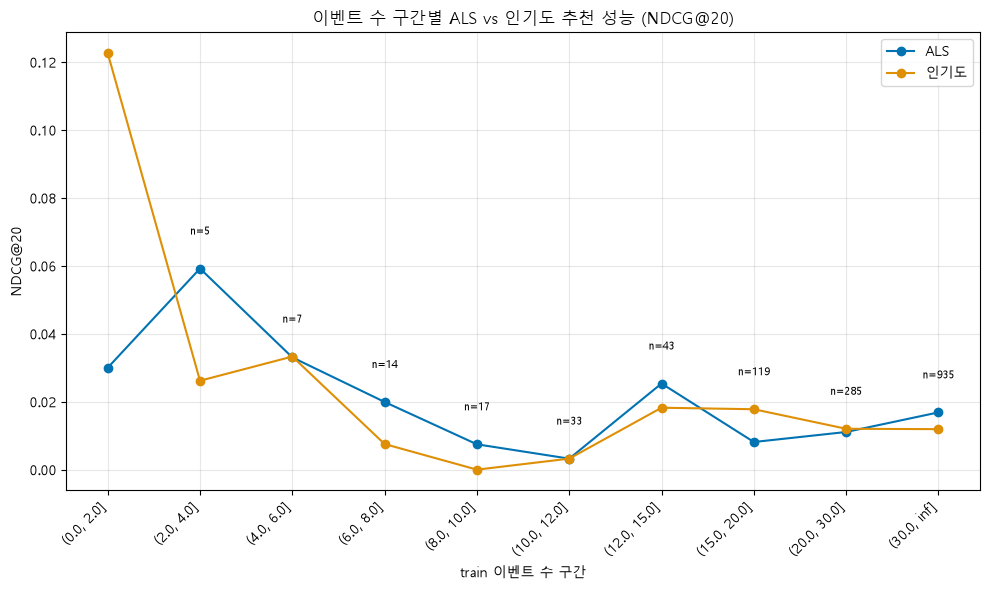

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(bin_summary))
ax.plot(x, bin_summary["als_ndcg"], marker="o", label="ALS", color=palette[0])
ax.plot(x, bin_summary["pop_ndcg"], marker="o", label="인기도", color=palette[1])
ax.set_xticks(list(x))
ax.set_xticklabels([str(b) for b in bin_summary["event_bin"]], rotation=45, ha="right")
ax.set_xlabel("train 이벤트 수 구간")
ax.set_ylabel(f"NDCG@{K}")
ax.set_title(f"이벤트 수 구간별 ALS vs 인기도 추천 성능 (NDCG@{K})")
ax.legend()
ax.grid(alpha=0.3)

for i, row in bin_summary.iterrows():
    y_max = max(row["als_ndcg"], row["pop_ndcg"])
    ax.annotate(f"n={row['n_users']}", (i, y_max + 0.01), fontsize=8, ha="center")

plt.tight_layout()
plt.show()

## 6-3. K 민감도 확인

구간별 비교는 K=10 기준이었다. `eval.k_list`의 다른 K값에서도 같은 경향(ALS ≥ 인기도)이
나타나는지 전체 유저 평균으로 확인한다.

In [10]:
k_sweep_rows = []
for k in params["eval"]["k_list"]:
    m_als = compute_user_metrics(df_als_recs, ground_truth, k)
    m_pop = compute_user_metrics(df_pop_recs, ground_truth, k)
    k_sweep_rows.append({
        "k": k,
        "als_hr": round(m_als["hr"].mean(), 4),
        "pop_hr": round(m_pop["hr"].mean(), 4),
        "als_ndcg": round(m_als["ndcg"].mean(), 4),
        "pop_ndcg": round(m_pop["ndcg"].mean(), 4),
    })

pd.DataFrame(k_sweep_rows)

,k,als_hr,pop_hr,als_ndcg,pop_ndcg
0,5,0.0171,0.0191,0.0073,0.0067
1,10,0.0362,0.0308,0.0111,0.0091
2,20,0.0602,0.0560,0.0152,0.0128


## 7. Threshold 후보 도출

`als_ndcg >= pop_ndcg`만으로 첫 구간을 고르면, 표본이 매우 작은 구간(n=5 등)에서
두 값이 우연히 0.0으로 동률이 되는 것만으로 candidate가 잡히는 문제가 있다(노이즈).
따라서 **최소 표본 수(`MIN_N`) 이상이고 ALS가 인기도보다 엄격히 높은(`>`) 첫 구간**만
후보로 인정한다.

In [11]:
MIN_N = 30  # 이 미만 표본의 구간은 지표가 불안정해 판단에서 제외

bin_summary_sorted = bin_summary.sort_values("event_bin")
reliable_bins = bin_summary_sorted[bin_summary_sorted["n_users"] >= MIN_N]
crossover_bins = reliable_bins[reliable_bins["als_ndcg"] > reliable_bins["pop_ndcg"]]

print(f"신뢰 가능 구간(n>={MIN_N}) 중 ALS > 인기도인 구간:")
print(crossover_bins[["event_bin", "n_users", "als_ndcg", "pop_ndcg", "als_minus_pop_ndcg"]].to_string(index=False))

if len(crossover_bins) > 0:
    first_crossover = crossover_bins.iloc[0]
    candidate_threshold = int(first_crossover["event_bin"].left)
    print(f"\ncold_threshold 후보(잠정): {candidate_threshold}  (margin={first_crossover['als_minus_pop_ndcg']:.4f} — 절대값이 작아 실질적 우위인지는 추가 검증 필요)")
else:
    print("\n신뢰 가능한 표본 크기에서 ALS가 인기도를 뚜렷이 앞서는 구간을 찾지 못함.")

print(f"\n현재 params.yaml의 cold_threshold: {params['cold_threshold']}")

신뢰 가능 구간(n>=30) 중 ALS > 인기도인 구간:
   event_bin  n_users  als_ndcg  pop_ndcg  als_minus_pop_ndcg
(12.0, 15.0]       43  0.025360  0.018233              0.0071
 (30.0, inf]      935  0.016859  0.011922              0.0049

cold_threshold 후보(잠정): 12  (margin=0.0071 — 절대값이 작아 실질적 우위인지는 추가 검증 필요)

현재 params.yaml의 cold_threshold: 10


## 분석 결과 (2026-07-03 재실행 — 신규 하이퍼파라미터, K=10/K=20 이중 확인)

**핵심 발견:**
- **전체 평균으로는 K=5를 제외한 모든 K에서 ALS가 인기도를 이긴다.** K=10: NDCG 0.0111 vs 0.0091,
  K=20: NDCG 0.0152 vs 0.0128 (6-3절). 하이퍼파라미터 튜닝 노트북 결론과 일치.
- **구간별(binned) 비교는 K=10과 K=20 둘 다에서 비단조적이다.** 신뢰 가능 구간(n≥30) 5개의
  ALS-인기도 우열이 K를 바꿔도 같은 패턴으로 뒤집힌다:

  | 구간 | n | K=10 (ALS−인기도) | K=20 (ALS−인기도) |
  |------|---|---------------------|---------------------|
  | (10,12] | 33 | −0.0032 | −0.0000 (거의 동률) |
  | (12,15] | 43 | **+0.0044** | **+0.0071** |
  | (15,20] | 119 | −0.0054 | **−0.0096** (K=20에서 격차 더 커짐) |
  | (20,30] | 285 | +0.0013 | −0.0009 |
  | (30,inf] | 935 | **+0.0038** | **+0.0049** |

  즉 (12,15] 구간에서 ALS가 이겼다가 바로 다음, 표본이 훨씬 큰 (15,20] 구간에서 다시 지는 패턴이
  K=10과 K=20 양쪽에서 **동일하게** 재현된다 — 우연한 노이즈가 아니라 이 데이터셋에서 실제로
  존재하는, 다만 threshold 하나로는 깔끔하게 설명 안 되는 비선형적 패턴으로 보인다.
- **두 K값 모두에서 일관되게 ALS가 이기는 구간은 (12,15]와 (30,inf] 두 곳뿐이며, 그중 (30,inf]가
  압도적으로 표본이 크다(n=935, 전체 비교 대상의 64%).** 나머지 구간은 K를 바꾸면 부호까지 바뀌거나
  거의 0에 가까워 신뢰하기 어렵다.
- 알고리즘이 기계적으로 뽑는 "첫 crossover 지점"은 K=10, K=20 둘 다 `12`로 동일하게 나오지만,
  바로 다음(더 큰 표본의) 구간에서 반복적으로 뒤집히므로 이 숫자를 그대로 신규 threshold로
  채택하는 것은 여전히 근거가 약하다.

**수치 요약 (전체 유저 평균):**

| K | ALS HR | 인기도 HR | ALS NDCG | 인기도 NDCG |
|---|--------|-----------|----------|--------------|
| 5 | 0.0171 | 0.0191 | 0.0073 | 0.0067 |
| 10 | 0.0362 | 0.0308 | 0.0111 | 0.0091 |
| 20 | 0.0602 | 0.0560 | 0.0152 | 0.0128 |

**해석 및 최종 추천:** K=10과 K=20 두 기준으로 교차 검증한 결과, 중간 활동 구간(15~30 이벤트)에서
ALS와 인기도의 우열은 K를 바꾸면 흔들릴 만큼 불안정하다. 반면 최대 표본 구간(30개 이상 이벤트,
전체 비교 대상의 64%)에서는 K=10, K=20 모두에서 ALS가 일관되게 앞선다.

**→ `cold_threshold`는 현재 값인 10을 그대로 유지하는 것을 추천한다.** 근거:
1. 중간 구간의 crossover가 K값에 따라 방향이 바뀔 만큼 불안정해, 특정 대안값(예: 12, 15, 20)을
   제시할 통계적 근거가 부족하다.
2. 신뢰할 수 있는 유일한 신호(30개 이상 구간)는 이미 현재 threshold=10 하에서도 ALS(Heavy 세그먼트)로
   분류돼 서비스되고 있어, threshold를 바꿔야만 얻어지는 추가 이득이 아니다.
3. 이미 전체 평균 기준으로 ALS가 인기도를 이기고 있는 상태라, threshold를 조정해서 얻는 한계 이득이
   하이퍼파라미터 개선 효과에 비해 작다.

**한계 및 잠재 편향:**
- K=10/K=20 교차검증도 결국 같은 test set을 재사용한 것이다 — 다만 하이퍼파라미터 자체를 다시
  고르는 게 아니라 이미 확정된 하이퍼파라미터 하에서 threshold 질문을 재확인한 것이라, 이번 재확인을
  포함해도 전체 프로젝트의 탐색 라운드 예산(3라운드) 원칙을 새로 어긴 것으로 보진 않는다.
- 표본 크기가 구간마다 5~935명으로 매우 불균등해 중간 구간의 crossover는 근본적으로 노이즈에
  취약한 설계다(`bin_edges` 자체가 임의로 정한 경계).
- purchase 이벤트만 정답으로 사용해 정답 집합 자체가 희소함(비교 대상 1,463명).

**권장 다음 단계:**
1. **`configs/ALS/params.yaml`의 `cold_threshold: 10`은 그대로 유지한다.**
2. 더 정밀한 threshold를 원한다면, 임의로 나눈 구간(bin) 대신 이벤트 수를 연속 변수로 쓰는
   회귀 기반 방법(로지스틱/GAM)으로 "ALS가 이길 확률"을 직접 추정하는 편이, 지금처럼 구간을
   나눠 crossover를 찾는 방식보다 K값에 덜 민감할 가능성이 높다 — 다만 이것도 validation split을
   먼저 구성한 뒤 시도하는 게 안전하다.
3. `als_model.py`의 `model.recommend_all()` deprecated 이슈는 이번 세션에서 이미 수정 완료됨.